In [1]:
# re-size all the images to this
IMAGE_SIZE = [224, 224]

In [2]:
train_path = "archive_extracted/train"
valid_path = "archive_extracted/test"

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
import numpy as np
from glob import glob
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, MaxPooling2D

In [4]:
from glob import glob

folders = glob("archive_extracted/train/*")
folders


['archive_extracted/train\\apples', 'archive_extracted/train\\tomatoes']

In [5]:
num_of_class = len(folders)
num_of_class

2

In [6]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(64,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

In [7]:
# view the structure of the model
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 26, 26, 128)       0

In [8]:
model.compile(
  loss='binary_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [11]:
training_set = train_datagen.flow_from_directory(train_path,
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'binary')

Found 294 images belonging to 2 classes.


In [12]:
test_set = test_datagen.flow_from_directory(valid_path,
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'binary')

Found 97 images belonging to 2 classes.


In [13]:
history = model.fit(
  training_set,
  validation_data=test_set,
  epochs=10,
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set)
)

Epoch 1/10
10/10 [==============================] - 17s 2s/step - loss: 0.9450 - accuracy: 0.5068 - val_loss: 0.6736 - val_accuracy: 0.5464
Epoch 2/10
10/10 [==============================] - 12s 1s/step - loss: 0.6911 - accuracy: 0.6293 - val_loss: 0.6505 - val_accuracy: 0.6804
Epoch 3/10
10/10 [==============================] - 13s 1s/step - loss: 0.6575 - accuracy: 0.6156 - val_loss: 0.6090 - val_accuracy: 0.7010
Epoch 4/10
10/10 [==============================] - 13s 1s/step - loss: 0.5834 - accuracy: 0.7075 - val_loss: 0.6151 - val_accuracy: 0.6701
Epoch 5/10
10/10 [==============================] - 13s 1s/step - loss: 0.5351 - accuracy: 0.7211 - val_loss: 0.9584 - val_accuracy: 0.4433
Epoch 6/10
10/10 [==============================] - 13s 1s/step - loss: 0.6309 - accuracy: 0.6463 - val_loss: 0.6225 - val_accuracy: 0.6598
Epoch 7/10
10/10 [==============================] - 13s 1s/step - loss: 0.5534 - accuracy: 0.7347 - val_loss: 0.5784 - val_accuracy: 0.6907
Epoch 8/10
10/10 [==

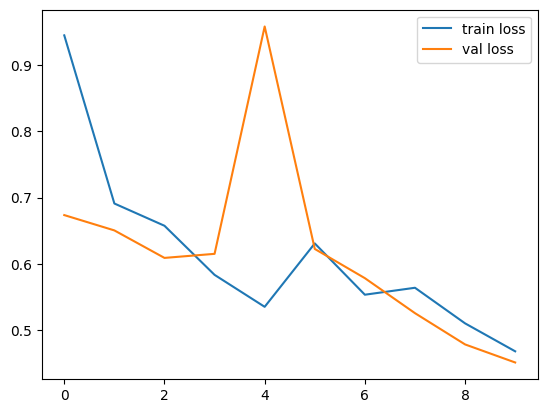

<Figure size 640x480 with 0 Axes>

In [14]:
import matplotlib.pyplot as plt
# plot the loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

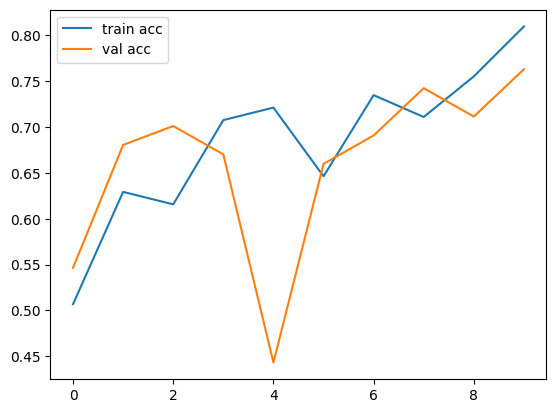

<Figure size 640x480 with 0 Axes>

In [15]:
# plot the accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

In [16]:
model.evaluate(test_set)

4/4 [==============================] - 1s 161ms/step - loss: 0.4511 - accuracy: 0.7629


[0.45108869671821594, 0.7628865838050842]

In [17]:
model.save('model.h5')

c:\Users\HP\Computer-Vision-Course\Vision\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [18]:
from tensorflow.keras.models import load_model

In [19]:
model = load_model("model.h5")

In [20]:
from tensorflow.keras.preprocessing import image

In [22]:
from tensorflow.keras.preprocessing import image

img = image.load_img("archive_extracted/train/tomatoes/img_p1_10.jpeg", target_size=(224, 224))

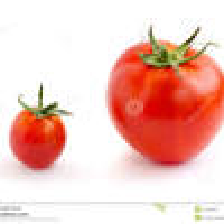

In [23]:
img

In [24]:
import numpy as np

In [25]:
x=image.img_to_array(img)
x=x/255

x=np.expand_dims(x,axis=0)
output = model.predict(x)
print(output)

1/1 [==============================] - 0s 190ms/step
[[0.5024701]]


In [26]:
x.shape

(1, 224, 224, 3)

In [27]:
output[0][0]

0.5024701

In [28]:
if output[0][0] >=0.5:
    prediction = 'Tomato'
    print(prediction)
else:
    prediction = 'Apple'
    print(prediction)

Tomato


In [29]:
print("The End")

The End
